### 1. Installs and Imports

#### 1. Installs

In [1]:
%pip install rioxarray rasterio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install tqdm shapely requests


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 2. Imports

In [2]:
import rioxarray
from shapely.geometry import box
import pandas as pd
import shutil
import os
import requests
from tqdm import tqdm
from zipfile import ZipFile
from rasterio.enums import Resampling
from datetime import datetime
import numpy as np

### 3. 30s resolution

Any var apart from bio is processed the same - see prec as example

In [ ]:
root_dir = "ReplaceWithYourPath/30secs/"
os.makedirs(root_dir, exist_ok=True)
data_types = ["prec", "bio"]

for data_type in data_types:
  local_filename = os.path.join(root_dir, f"{data_type}.zip")
  url = f"https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_30s_{data_type}.zip"
  with requests.get(url, stream=True) as r:
        if r.status_code == 200:
            with open(local_filename, 'wb') as f:
                total_size = int(r.headers.get('content-length', 0))
                with tqdm(total=total_size, unit='B', unit_scale=True, desc=local_filename) as pbar:
                  for chunk in r.iter_content(chunk_size=8192):  # Download in chunks
                      f.write(chunk)
            print(f"Downloaded: {local_filename}")

/content/drive/MyDrive/RACamcore/30s/elev.zip:   0%|          | 0.00/338M [00:56<?, ?B/s]

Downloaded: /content/drive/MyDrive/RACamcore/30s/elev.zip


In [ ]:
def unzip_and_cleanup(current_dir):
    # List all zip files
    zip_files = [os.path.join(root, file) for root, dirs, files in os.walk(current_dir) for file in files if file.endswith('.zip')]

    print(f"Found {len(zip_files)} zip files.")

    # Unzip each zip file into its directory
    for zip_file in zip_files:
        folder = os.path.dirname(zip_file)  # Directory where zip file is
        extract_foler = os.path.join(folder,zip_file.split(".")[0])
        # os.makedirs(zip_file, exist_ok=True)  # Create directory if it doesn't exist
        try:
            with ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(extract_foler)  # Extract contents to the same folder
            print(f"Unzipped: {zip_file} into {extract_foler}")
            # os.remove(zip_file)  # Remove the zip file after extraction
        except Exception as e:
            print(f"Failed to unzip {zip_file}: {e}")

In [ ]:
unzip_and_cleanup(root_dir)

#### 2.  Clipping to extent of a specific bounding box

In [ ]:
# Define bounding box coordinates
lat_min, lat_max = -19.85, -19.80
lon_min, lon_max = -40.35, -40.30
raster = rioxarray.open_rasterio(
    "ReplaceWithYourPath/30s/bio/wc2.1_30s_bio_1.tif",
    mask_and_scale=True,
)
# Clip the raster using the new bounding box coordinates
xdscn = raster.rio.clip_box(
    minx=lon_min,
    miny=lat_min,
    maxx=lon_max,
    maxy=lat_max,
    allow_one_dimensional_raster=True
)

In [ ]:
xdscn

<xarray.DataArray (band: 1, y: 6, x: 6)> Size: 144B
[36 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 48B -40.35 -40.34 -40.33 -40.32 -40.31 -40.3
  * y            (y) float64 48B -19.8 -19.81 -19.82 -19.83 -19.84 -19.85
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.387500762939
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.770832061768
    STATISTICS_STDDEV:   nan

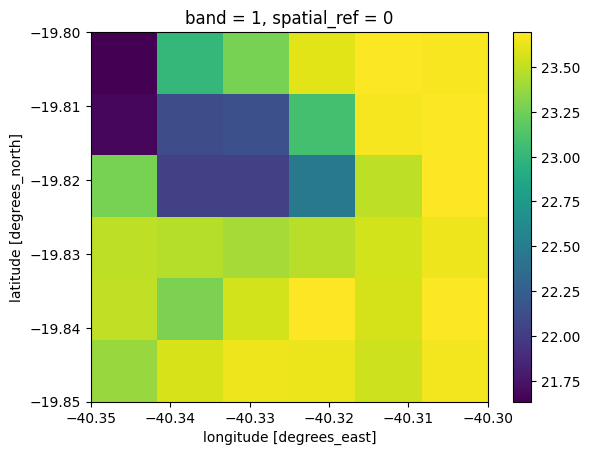

In [ ]:
xdscn.plot()

#### 3. One var to csv

In [ ]:
# Check values inside the bounding box (after clipping)
clipped_values = xdscn.values
print(clipped_values)

[[[21.633333 23.004168 23.270834 23.604166 23.683334 23.675001]
  [21.666666 22.108334 22.133333 23.083334 23.670834 23.683334]
  [23.270834 22.033333 22.029167 22.470833 23.4875   23.695833]
  [23.491667 23.4625   23.420834 23.475    23.554167 23.645834]
  [23.5      23.2875   23.554167 23.691668 23.566668 23.683334]
  [23.379166 23.570833 23.645834 23.6375   23.541666 23.6625  ]]]


In [ ]:
rds = xdscn.squeeze().drop("spatial_ref").drop("band")
rds.name = "w_bio1"
df = rds.to_dadtaframe().reset_index()
df_filtered = df[df.w_bio1.notna() & (df.w_bio1 >= 0.0)]
df_filtered.to_csv("w_bio1.csv", index=False)

<ipython-input-36-eec1604d1ee0>:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  rds = xdscn.squeeze().drop("spatial_ref").drop("band")


In [ ]:
df_filtered.head()

,y,x,w_bio1
0,-19.804167,-40.345833,21.633333
1,-19.804167,-40.337500,23.004168
2,-19.804167,-40.329167,23.270834
3,-19.804167,-40.320833,23.604166
4,-19.804167,-40.312500,23.683334


In [ ]:
df_filtered['location'] = df_filtered.apply(lambda row: f"lat{row['x']:.2f}_lon{row['y']:.2f}", axis=1)
df_filtered.drop(columns=["x","y"], inplace=True,axis=1)
df_filtered.head()

,w_bio1,location
0,21.633333,lat-40.35_lon-19.80
1,23.004168,lat-40.34_lon-19.80
2,23.270834,lat-40.33_lon-19.80
3,23.604166,lat-40.32_lon-19.80
4,23.683334,lat-40.31_lon-19.80


In [ ]:
len(df_filtered["location"].unique()) == len(df_filtered)

True

In [ ]:
len(df_filtered)

36

#### 4. Loop for bio vars

In [ ]:
final_df = None
for i in range(1,20):
  raster = rioxarray.open_rasterio(
      f"ReplaceWithYourPath/30s/bio/wc2.1_30s_bio_{i}.tif",
      mask_and_scale=True,
  )
  # Clip the raster using the new bounding box coordinates
  xdscn = raster.rio.clip_box(
      minx=lon_min,
      miny=lat_min,
      maxx=lon_max,
      maxy=lat_max,
      allow_one_dimensional_raster=True
  )
  rds = xdscn.squeeze().drop_vars("spatial_ref").drop_vars("band")
  rds.name = f"w_bio{i}"
  name_var = rds.name
  df = rds.to_dataframe().reset_index()
  df_filtered = df[df[name_var].notna()]
  df_filtered['location'] = df_filtered.apply(lambda row: f"lat{row['x']:.2f}_lon{row['y']:.2f}", axis=1)
  df_filtered.drop(columns=["x","y"], inplace=True,axis=1)
  # Select only the `location` and `w_bio` columns
  df = df_filtered[['location', rds.name]]

    # Join with the main DataFrame
  if final_df is None:
    final_df = df
  else:
    final_df = final_df.merge(df, on='location', how='outer')
# Preview the final DataFrame
final_df.head()

,location,w_bio1,w_bio2,w_bio3,w_bio4,w_bio5,w_bio6,w_bio7,w_bio8,w_bio9,w_bio10,w_bio11,w_bio12,w_bio13,w_bio14,w_bio15,w_bio16,w_bio17,w_bio18,w_bio19
0,lat-40.30_lon-19.80,23.675001,9.583333,61.431622,197.455414,31.200001,15.6,15.6,25.183334,21.700001,26.066668,21.183334,1234.0,193.0,45.0,51.210461,536.0,153.0,353.0,154.0
1,lat-40.30_lon-19.81,23.683334,9.566667,61.324783,196.565201,31.200001,15.6,15.6,25.183334,21.200001,26.066668,21.200001,1233.0,193.0,45.0,51.301487,537.0,154.0,351.0,154.0
2,lat-40.30_lon-19.82,23.695833,9.575000,61.378201,196.740005,31.200001,15.6,15.6,25.183334,21.216667,26.083334,21.216667,1232.0,193.0,45.0,51.267223,536.0,154.0,349.0,154.0
3,lat-40.30_lon-19.83,23.645834,9.558333,61.666668,197.466431,31.100000,15.6,15.5,25.166668,21.683334,26.016666,21.150000,1233.0,193.0,46.0,51.260315,536.0,155.0,349.0,155.0
4,lat-40.30_lon-19.84,23.683334,9.549999,61.217945,196.403275,31.200001,15.6,15.6,25.183334,21.716667,26.066668,21.216667,1232.0,193.0,47.0,51.194572,535.0,155.0,349.0,155.0


#### 5. Loop for other vars and take avg over months

In [ ]:
final_df_prec = None
for i in range(1,13):
  raster = rioxarray.open_rasterio(
      f"ReplaceWithYourPath/30s/prec/wc2.1_30s_prec_{i:02d}.tif",
      mask_and_scale=True,
  )
  # Clip the raster using the new bounding box coordinates
  xdscn = raster.rio.clip_box(
      minx=lon_min,
      miny=lat_min,
      maxx=lon_max,
      maxy=lat_max,
      allow_one_dimensional_raster=True
  )
  rds = xdscn.squeeze().drop_vars("spatial_ref").drop_vars("band")
  rds.name = f"w_prec{i}"
  name_var = rds.name
  df = rds.to_dataframe().reset_index()
  df_filtered = df[df[name_var].notna()]
  df_filtered['location'] = df_filtered.apply(lambda row: f"lat{row['x']:.2f}_lon{row['y']:.2f}", axis=1)
  df_filtered.drop(columns=["x","y"], inplace=True,axis=1)
  # Select only the `location` and `w_bio` columns
  df = df_filtered[['location', rds.name]]
#   df.
    # Join with the main DataFrame
  if final_df_prec is None:
    final_df_prec = df
  else:
    final_df_prec = final_df_prec.merge(df, on='location', how='outer')
# Preview the final DataFrame
final_df_prec.head()

,location,w_prec1,w_prec2,w_prec3,w_prec4,w_prec5,w_prec6,w_prec7,w_prec8,w_prec9,w_prec10,w_prec11,w_prec12
0,lat-40.30_lon-19.80,154.0,85.0,114.0,88.0,54.0,45.0,54.0,55.0,71.0,132.0,193.0,189.0
1,lat-40.30_lon-19.81,155.0,83.0,113.0,88.0,55.0,45.0,55.0,54.0,71.0,132.0,193.0,189.0
2,lat-40.30_lon-19.82,154.0,82.0,113.0,89.0,55.0,45.0,55.0,54.0,71.0,132.0,193.0,189.0
3,lat-40.30_lon-19.83,154.0,82.0,113.0,89.0,54.0,46.0,55.0,54.0,71.0,133.0,193.0,189.0
4,lat-40.30_lon-19.84,153.0,83.0,113.0,88.0,54.0,47.0,54.0,54.0,71.0,133.0,193.0,189.0


In [ ]:
w_prec_columns = [col for col in final_df_prec.columns if col.startswith("w_prec")]
final_df_prec["w_prec"] = final_df_prec[w_prec_columns].mean(axis=1)

In [ ]:
final_df_prec = final_df_prec[["location","w_prec"]]

In [ ]:
final_df_prec.head()

,location,w_prec
0,lat-40.30_lon-19.80,102.833336
1,lat-40.30_lon-19.81,102.750000
2,lat-40.30_lon-19.82,102.666664
3,lat-40.30_lon-19.83,102.750000
4,lat-40.30_lon-19.84,102.666664


In [ ]:
final_df.head()

,location,w_bio1,w_bio2,w_bio3,w_bio4,w_bio5,w_bio6,w_bio7,w_bio8,w_bio9,w_bio10,w_bio11,w_bio12,w_bio13,w_bio14,w_bio15,w_bio16,w_bio17,w_bio18,w_bio19
0,lat-40.30_lon-19.80,23.675001,9.583333,61.431622,197.455414,31.200001,15.6,15.6,25.183334,21.700001,26.066668,21.183334,1234.0,193.0,45.0,51.210461,536.0,153.0,353.0,154.0
1,lat-40.30_lon-19.81,23.683334,9.566667,61.324783,196.565201,31.200001,15.6,15.6,25.183334,21.200001,26.066668,21.200001,1233.0,193.0,45.0,51.301487,537.0,154.0,351.0,154.0
2,lat-40.30_lon-19.82,23.695833,9.575000,61.378201,196.740005,31.200001,15.6,15.6,25.183334,21.216667,26.083334,21.216667,1232.0,193.0,45.0,51.267223,536.0,154.0,349.0,154.0
3,lat-40.30_lon-19.83,23.645834,9.558333,61.666668,197.466431,31.100000,15.6,15.5,25.166668,21.683334,26.016666,21.150000,1233.0,193.0,46.0,51.260315,536.0,155.0,349.0,155.0
4,lat-40.30_lon-19.84,23.683334,9.549999,61.217945,196.403275,31.200001,15.6,15.6,25.183334,21.716667,26.066668,21.216667,1232.0,193.0,47.0,51.194572,535.0,155.0,349.0,155.0


In [ ]:
table  = pd.merge(final_df_prec, final_df, on="location", how="inner")

In [ ]:
table.head()

,location,w_prec,w_bio1,w_bio2,w_bio3,w_bio4,w_bio5,w_bio6,w_bio7,w_bio8,...,w_bio10,w_bio11,w_bio12,w_bio13,w_bio14,w_bio15,w_bio16,w_bio17,w_bio18,w_bio19
0,lat-40.30_lon-19.80,102.833336,23.675001,9.583333,61.431622,197.455414,31.200001,15.6,15.6,25.183334,...,26.066668,21.183334,1234.0,193.0,45.0,51.210461,536.0,153.0,353.0,154.0
1,lat-40.30_lon-19.81,102.750000,23.683334,9.566667,61.324783,196.565201,31.200001,15.6,15.6,25.183334,...,26.066668,21.200001,1233.0,193.0,45.0,51.301487,537.0,154.0,351.0,154.0
2,lat-40.30_lon-19.82,102.666664,23.695833,9.575000,61.378201,196.740005,31.200001,15.6,15.6,25.183334,...,26.083334,21.216667,1232.0,193.0,45.0,51.267223,536.0,154.0,349.0,154.0
3,lat-40.30_lon-19.83,102.750000,23.645834,9.558333,61.666668,197.466431,31.100000,15.6,15.5,25.166668,...,26.016666,21.150000,1233.0,193.0,46.0,51.260315,536.0,155.0,349.0,155.0
4,lat-40.30_lon-19.84,102.666664,23.683334,9.549999,61.217945,196.403275,31.200001,15.6,15.6,25.183334,...,26.066668,21.216667,1232.0,193.0,47.0,51.194572,535.0,155.0,349.0,155.0


In [ ]:
table.to_csv("table.csv", index=False)

### 4. 2.5m resolution

##### 1. Define Location and date range

In [177]:
lat_center, lon_center = -38.600000, -72.400000	
lat_size = 0.05
lon_size = 0.05
lat_min = lat_center - (lat_size / 2)
lat_max = lat_center + (lat_size / 2)
lon_min = lon_center - (lon_size / 2)
lon_max = lon_center + (lon_size / 2)
date_range = ["9/1/1996", "8/30/2004"]

# Check the result
date_format = "%m/%d/%Y"  # Format used in the date strings
start_date = datetime.strptime(date_range[0], date_format).date()
end_date = datetime.strptime(date_range[1], date_format).date()

# Print the results
print(f"Start date: {start_date}")
print(f"End date: {end_date}")
print(f"Latitude range: {lat_min} to {lat_max}")
print(f"Longitude range: {lon_min} to {lon_max}")

Start date: 1996-09-01
End date: 2004-08-30
Latitude range: -38.625 to -38.575
Longitude range: -72.42500000000001 to -72.375


#### 2. Resampled CSV from each data type - DO NOT RERUN

In [7]:
root_dir = 'D:/hyarram/WorldClim/1.5ms/'
os.makedirs(root_dir, exist_ok=True)

data_types = ['tmin', 'tmax', 'prec']

def download_file(url, target_folder):
    local_filename = os.path.join(target_folder, url.split('/')[-1])  # Get the file name from URL
    with requests.get(url, stream=True) as r:
        if r.status_code == 200:
            with open(local_filename, 'wb') as f:
                total_size = int(r.headers.get('content-length', 0))
                with tqdm(total=total_size, unit='B', unit_scale=True, desc=local_filename) as pbar:
                  for chunk in r.iter_content(chunk_size=8192): 
                      f.write(chunk)
                      pbar.update(len(chunk))
            print(f"Downloaded: {local_filename}")
            unzip_and_cleanup(target_folder)
        else:
            print(f"Failed to download: {url}")

def unzip_and_cleanup(current_dir):
    # List all zip files
    zip_files = [os.path.join(root, file) for root, _, files in os.walk(current_dir) for file in files if file.endswith('.zip')]

    print(f"Found {len(zip_files)} zip files.")

    # Unzip each zip file into its directory
    for zip_file in zip_files:
        folder = os.path.dirname(zip_file)  # Directory where zip file is
        print(folder,zip_file)
        try:
            with ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(folder)  # Extract contents to the same folder
            print(f"Unzipped: {zip_file} into {folder}")
            os.remove(zip_file)  # Remove the zip file after extraction
        except Exception as e:
            print(f"Failed to unzip {zip_file}: {e}")

# Function to download data for each year block dynamically
def download_data():
    for start_year in range(1960, 2020, 10):  # Start at 1960 and go up to 2020 with a step of 10 years
        end_year = start_year + 9  # End year for the 10-year block
        year_block = f'{start_year}-{end_year}'

        # For each data type (tmin, tmax, prec)
        for data_type in data_types:
            # Construct the download URL dynamically based on year and data type
            file_url = f'https://geodata.ucdavis.edu/climate/worldclim/2_1/hist/cts4.06/2.5m/wc2.1_cruts4.06_2.5m_{data_type}_{year_block}.zip'

            # Construct the target folder based on data type and year
            target_folder = os.path.join(root_dir, data_type, year_block)
            os.makedirs(target_folder, exist_ok=True)

            # Download the file
            download_file(file_url, target_folder)

download_data()

def organize_files_by_year_in_decade():
    # Traverse each data type directory (tmax, tmin, prec)
    for data_type in data_types:
        data_type_dir = os.path.join(root_dir, data_type)

        if not os.path.exists(data_type_dir):
            print(f"Directory does not exist: {data_type_dir}")
            continue

        for decade_folder in os.listdir(data_type_dir):
            decade_path = os.path.join(data_type_dir, decade_folder)

            if not os.path.isdir(decade_path):
                continue  # Skip if it's not a folder

            print(f"Processing {decade_path}...")

            # Process all files in the decade folder
            for file_name in tqdm(os.listdir(decade_path), desc=f"Organizing {decade_folder}"):
                if file_name.endswith('.tif'):
                    year = file_name.split('-')[0][-4:]  # Last 4 digits of the first part
                    # Create a subfolder for the year
                    year_folder = os.path.join(decade_path, year)
                    os.makedirs(year_folder, exist_ok=True)

                    # Move the file to the year folder
                    src_file = os.path.join(decade_path, file_name)
                    dest_file = os.path.join(year_folder, file_name)
                    shutil.move(src_file, dest_file)

    print("File organization completed.")

# Run the organization script
organize_files_by_year_in_decade()

D:/hyarram/WorldClim/1.5ms/tmin\1960-1969\wc2.1_cruts4.06_2.5m_tmin_1960-1969.zip:   3%|▎         | 27.3M/818M [02:16<1:06:14, 199kB/s] 


KeyboardInterrupt: 

#### 3. Get season

In [9]:
def get_season(month):
    month = int(month)
    season = ""
    if month in [12, 1, 2]:
        season =  "Summer"
    elif month in [3, 4, 5]:
        season = "Autumn"
    elif month in [6, 7, 8]:
        season = "Winter"
    else:
        season = "Spring"
    return season

#### 4. Get the ratsers to dfs

In [ ]:
data_types = ["prec", "tmax", "tmin"]
root_dir = "./WorldClimSubset/"
all_data = {"prec": [], "tmax": [], "tmin": []}

for data_type in data_types:
    data_type_path = os.path.join(root_dir, data_type)
    
    for year_block in os.listdir(data_type_path):
        year_block_path = os.path.join(data_type_path, year_block)

        for year in os.listdir(year_block_path):
            try:
                year_int = int(year)
                if year_int < start_date.year or year_int > end_date.year:
                    continue  # Skip years outside the range
            except ValueError:
                continue  # Skip if the folder name is not a valid year
            
            year_path = os.path.join(year_block_path, year)

            # Determine valid months for the given year
            if year_int == start_date.year:
                start_month = start_date.month
            else:
                start_month = 1  # Default to January

            if year_int == end_date.year:
                end_month = end_date.month
            else:
                end_month = 12  # Default to December

            for month in range(start_month, end_month + 1):  # Process only valid months
                month_str = f"{month:02d}"
                date_str = f"{year}-{month_str}-01"  # Construct YYYY-MM-DD format

                tif_filename = f"wc2.1_2.5m_{data_type}_{year}-{month_str}.tif"
                print(f"Processing: {tif_filename}")
                tif_filepath = os.path.join(year_path, tif_filename)

                if os.path.exists(tif_filepath):
                    try:
                        xds__2p5m = rioxarray.open_rasterio(
                            tif_filepath, mask_and_scale=True
                        )
                        xds__2p5m_clipped = xds__2p5m.rio.clip_box(
                            minx=lon_min,
                            miny=lat_min,
                            maxx=lon_max,
                            maxy=lat_max,
                            allow_one_dimensional_raster=True
                        )
                        xds_match_30s_sample = rioxarray.open_rasterio("./wc2.1_30s_prec_01.tif",mask_and_scale=True,)
                        xds_match_30s_clipped_sample = xds_match_30s_sample.rio.clip_box(
                        minx=lon_min,
                        miny=lat_min,
                        maxx=lon_max,
                        maxy=lat_max,
                        allow_one_dimensional_raster=True,
                        )
                        xds__2p5m_clipped_upsampled = xds__2p5m_clipped.rio.reproject_match(
                            xds_match_30s_clipped_sample, resampling=Resampling.cubic_spline
                        )
                        rds = xds__2p5m_clipped_upsampled.squeeze().drop_vars("spatial_ref").drop_vars("band")
                        rds.name = f"{data_type}_{year}_{month_str}"
                        df = rds.to_dataframe().reset_index()
                        df[f'season_{rds.name}'] = get_season(month)
                        all_data[f"{data_type}"].append(df)
                    except Exception as e:
                        print(f"Error processing {tif_filename}: {e}")
                        continue

Processing: wc2.1_2.5m_prec_1996-09.tif
Processing: wc2.1_2.5m_prec_1996-10.tif
Processing: wc2.1_2.5m_prec_1996-11.tif
Processing: wc2.1_2.5m_prec_1996-12.tif
Processing: wc2.1_2.5m_prec_1997-01.tif
Processing: wc2.1_2.5m_prec_1997-02.tif
Processing: wc2.1_2.5m_prec_1997-03.tif
Processing: wc2.1_2.5m_prec_1997-04.tif
Processing: wc2.1_2.5m_prec_1997-05.tif
Processing: wc2.1_2.5m_prec_1997-06.tif
Processing: wc2.1_2.5m_prec_1997-07.tif
Processing: wc2.1_2.5m_prec_1997-08.tif
Processing: wc2.1_2.5m_prec_1997-09.tif
Processing: wc2.1_2.5m_prec_1997-10.tif
Processing: wc2.1_2.5m_prec_1997-11.tif
Processing: wc2.1_2.5m_prec_1997-12.tif
Processing: wc2.1_2.5m_prec_1998-01.tif
Processing: wc2.1_2.5m_prec_1998-02.tif
Processing: wc2.1_2.5m_prec_1998-03.tif
Processing: wc2.1_2.5m_prec_1998-04.tif
Processing: wc2.1_2.5m_prec_1998-05.tif
Processing: wc2.1_2.5m_prec_1998-06.tif
Processing: wc2.1_2.5m_prec_1998-07.tif
Processing: wc2.1_2.5m_prec_1998-08.tif
Processing: wc2.1_2.5m_prec_1998-09.tif


In [182]:
all_data["prec"][0].head()

,y,x,prec_1996_09,season_prec_1996_09
0,-38.579167,-72.429167,47.966934,Spring
1,-38.579167,-72.420833,48.240788,Spring
2,-38.579167,-72.412500,48.524666,Spring
3,-38.579167,-72.404167,48.798519,Spring
4,-38.579167,-72.395833,49.037483,Spring


In [183]:
all_data["prec"][0]["distance"] = np.sqrt((all_data["prec"][0]["y"] - lat_center) ** 2 + (all_data["prec"][0]["x"] - lon_center) ** 2)
all_data["prec"][0].head()  
# Select the row with the minimum distance
closest_row = all_data["prec"][0].loc[all_data["prec"][0]["distance"].idxmin()]

all_data["prec"][0].drop(columns=["distance"], inplace=True)

print(closest_row["x"])

-72.40416666666667


In [184]:
filtered_dfs_prec = [df[(df["x"] == closest_row["x"]) & (df["y"] == closest_row["y"])] for df in all_data["prec"]]

In [185]:
filtered_dfs_tmax = [df[(df["x"] == closest_row["x"]) & (df["y"] == closest_row["y"])] for df in all_data["tmax"]]

In [186]:
filtered_dfs_tmin = [df[(df["x"] == closest_row["x"]) & (df["y"] == closest_row["y"])] for df in all_data["tmin"]]

In [187]:
merged_df_prec = filtered_dfs_prec[0]  # Start with the first dataframe

# Merge all the dataframes
for df in filtered_dfs_prec[1:]:
    merged_df_prec = pd.merge(merged_df_prec, df, on=["x", "y"], how="outer")

In [188]:
merged_df_tmax = filtered_dfs_tmax[0]  # Start with the first dataframe

# Merge all the dataframes
for df in filtered_dfs_tmax[1:]:
    merged_df_tmax = pd.merge(merged_df_tmax, df, on=["x", "y"], how="outer")

In [189]:
merged_df_tmin = filtered_dfs_tmin[0]  # Start with the first dataframe

# Merge all the dataframes
for df in filtered_dfs_tmin[1:]:
    merged_df_tmin = pd.merge(merged_df_tmin, df, on=["x", "y"], how="outer")

In [190]:
merged_df_prec.head()

,y,x,prec_1996_09,season_prec_1996_09,prec_1996_10,season_prec_1996_10,prec_1996_11,season_prec_1996_11,prec_1996_12,season_prec_1996_12,...,prec_2004_04,season_prec_2004_04,prec_2004_05,season_prec_2004_05,prec_2004_06,season_prec_2004_06,prec_2004_07,season_prec_2004_07,prec_2004_08,season_prec_2004_08
0,-38.604167,-72.404167,49.001022,Spring,53.501022,Spring,64.110573,Spring,26.886219,Summer,...,176.72879,Autumn,16.862394,Autumn,331.0961,Winter,247.130753,Winter,140.746338,Winter


In [191]:
merged_df_tmax.head()

,y,x,tmax_1996_09,season_tmax_1996_09,tmax_1996_10,season_tmax_1996_10,tmax_1996_11,season_tmax_1996_11,tmax_1996_12,season_tmax_1996_12,...,tmax_2004_04,season_tmax_2004_04,tmax_2004_05,season_tmax_2004_05,tmax_2004_06,season_tmax_2004_06,tmax_2004_07,season_tmax_2004_07,tmax_2004_08,season_tmax_2004_08
0,-38.604167,-72.404167,16.0,Spring,17.552408,Spring,20.0,Spring,21.552408,Summer,...,17.0,Autumn,13.0,Autumn,12.8,Winter,11.0,Winter,12.861897,Winter


In [192]:
merged_df_tmin.head()

,y,x,tmin_1996_09,season_tmin_1996_09,tmin_1996_10,season_tmin_1996_10,tmin_1996_11,season_tmin_1996_11,tmin_1996_12,season_tmin_1996_12,...,tmin_2004_04,season_tmin_2004_04,tmin_2004_05,season_tmin_2004_05,tmin_2004_06,season_tmin_2004_06,tmin_2004_07,season_tmin_2004_07,tmin_2004_08,season_tmin_2004_08
0,-38.604167,-72.404167,4.0,Spring,6.0,Spring,7.0,Spring,9.0,Summer,...,7.0,Autumn,2.0,Autumn,5.0,Winter,4.0,Winter,3.0,Winter


In [193]:
id_vars = ['y', 'x']  # Columns that should remain unchanged
value_vars = [col for col in merged_df_prec.columns if col not in id_vars]  # All precipitation and season columns

# Melting the DataFrame
df_long = pd.melt(merged_df_prec, id_vars=id_vars, value_vars=value_vars, var_name="variable", value_name="value")

# Extracting year, month, and type (prec or season) from column names
df_long[['type', 'year', 'month']] = df_long['variable'].str.extract(r'(\w+)_(\d{4})_(\d{2})')

# Pivoting to get separate 'prec' and 'season' columns
prec_df = df_long.pivot_table(index=['y', 'x', 'year', 'month'], columns='type', values='value', aggfunc='first').reset_index()

# Renaming columns
prec_df.columns.name = None
prec_df = prec_df.rename(columns={'prec': 'precipitation', 'season': 'season'})

# Convert year and month to integers
prec_df['year'] = prec_df['year'].astype(int)
prec_df['month'] = prec_df['month'].astype(int)

prec_df.head(20)

,y,x,year,month,precipitation,season_prec
0,-38.604167,-72.404167,1996,9,49.001022,Spring
1,-38.604167,-72.404167,1996,10,53.501022,Spring
2,-38.604167,-72.404167,1996,11,64.110573,Spring
3,-38.604167,-72.404167,1996,12,26.886219,Summer
4,-38.604167,-72.404167,1997,1,51.073429,Summer
5,-38.604167,-72.404167,1997,2,23.921461,Summer
6,-38.604167,-72.404167,1997,3,2.829051,Autumn
7,-38.604167,-72.404167,1997,4,204.763596,Autumn
8,-38.604167,-72.404167,1997,5,183.934982,Autumn
9,-38.604167,-72.404167,1997,6,363.347015,Winter


In [194]:
# Assuming merged_df_prec is your DataFrame
id_vars = ['y', 'x']  # Columns that should remain unchanged
value_vars = [col for col in merged_df_tmax.columns if col not in id_vars]  # All precipitation and season columns

# Melting the DataFrame
df_long = pd.melt(merged_df_tmax, id_vars=id_vars, value_vars=value_vars, var_name="variable", value_name="value")

# Extracting year, month, and type (prec or season) from column names
df_long[['type', 'year', 'month']] = df_long['variable'].str.extract(r'(\w+)_(\d{4})_(\d{2})')

# Pivoting to get separate 'prec' and 'season' columns
tmax_df = df_long.pivot_table(index=['y', 'x', 'year', 'month'], columns='type', values='value', aggfunc='first').reset_index()

# Renaming columns
tmax_df.columns.name = None
tmax_df = tmax_df.rename(columns={'tmax': 'maxtemperature', 'season': 'season'})

# Convert year and month to integers
tmax_df['year'] = tmax_df['year'].astype(int)
tmax_df['month'] = tmax_df['month'].astype(int)

tmax_df.head(20)

,y,x,year,month,season_tmax,maxtemperature
0,-38.604167,-72.404167,1996,9,Spring,16.0
1,-38.604167,-72.404167,1996,10,Spring,17.552408
2,-38.604167,-72.404167,1996,11,Spring,20.0
3,-38.604167,-72.404167,1996,12,Summer,21.552408
4,-38.604167,-72.404167,1997,1,Summer,25.0
5,-38.604167,-72.404167,1997,2,Summer,23.614307
6,-38.604167,-72.404167,1997,3,Autumn,22.861898
7,-38.604167,-72.404167,1997,4,Autumn,20.0
8,-38.604167,-72.404167,1997,5,Autumn,15.0
9,-38.604167,-72.404167,1997,6,Winter,12.861897


In [195]:
# Assuming merged_df_prec is your DataFrame
id_vars = ['y', 'x']  # Columns that should remain unchanged
value_vars = [col for col in merged_df_tmin.columns if col not in id_vars]  # All precipitation and season columns

# Melting the DataFrame
df_long = pd.melt(merged_df_tmin, id_vars=id_vars, value_vars=value_vars, var_name="variable", value_name="value")

# Extracting year, month, and type (prec or season) from column names
df_long[['type', 'year', 'month']] = df_long['variable'].str.extract(r'(\w+)_(\d{4})_(\d{2})')

# Pivoting to get separate 'prec' and 'season' columns
tmin_df = df_long.pivot_table(index=['y', 'x', 'year', 'month'], columns='type', values='value', aggfunc='first').reset_index()

# Renaming columns
tmin_df.columns.name = None
tmin_df = tmin_df.rename(columns={'tmin': 'mintemperature', 'season': 'season'})

# Convert year and month to integers
tmin_df['year'] = tmin_df['year'].astype(int)
tmin_df['month'] = tmin_df['month'].astype(int)

tmin_df.head(20)

,y,x,year,month,season_tmin,mintemperature
0,-38.604167,-72.404167,1996,9,Spring,4.0
1,-38.604167,-72.404167,1996,10,Spring,6.0
2,-38.604167,-72.404167,1996,11,Spring,7.0
3,-38.604167,-72.404167,1996,12,Summer,9.0
4,-38.604167,-72.404167,1997,1,Summer,10.0
5,-38.604167,-72.404167,1997,2,Summer,7.0
6,-38.604167,-72.404167,1997,3,Autumn,8.0
7,-38.604167,-72.404167,1997,4,Autumn,8.0
8,-38.604167,-72.404167,1997,5,Autumn,5.0
9,-38.604167,-72.404167,1997,6,Winter,4.861898


In [196]:
merged_df = prec_df.merge(tmax_df, on=['y', 'x', 'year', 'month'], how='inner') \
                   .merge(tmin_df, on=['y', 'x', 'year', 'month'], how='inner')
merged_df.drop(columns=["x","y","season_tmax","season_tmin"], inplace=True,axis=1)
merged_df.rename(columns={"season_prec":"season"}, inplace=True)
merged_df.head()

,year,month,precipitation,season,maxtemperature,mintemperature
0,1996,9,49.001022,Spring,16.0,4.0
1,1996,10,53.501022,Spring,17.552408,6.0
2,1996,11,64.110573,Spring,20.0,7.0
3,1996,12,26.886219,Summer,21.552408,9.0
4,1997,1,51.073429,Summer,25.0,10.0


#### 5. Get the covariables 

##### Maximum precipitation corrected (mm/day) in all 4 seasons.

In [197]:
res = merged_df.groupby(["year","season"])['precipitation'].max().groupby("season").mean()
wm_prec1_autumn = res.iloc[0]  # Autumn
wm_prec1_spring = res.iloc[1]  # Spring
wm_prec1_summer = res.iloc[2]  # Summer
wm_prec1_winter = res.iloc[3]  # Winter


##### Median precipitation corrected (mm/day) in all 4 seasons

In [198]:
res = merged_df.groupby(["year","season"])['precipitation'].median().groupby("season").mean()
print(res)
wm_prec2_autumn = res.iloc[0]  # Autumn
wm_prec2_spring = res.iloc[1]  # Spring
wm_prec2_summer = res.iloc[2]  # Summer
wm_prec2_winter = res.iloc[3]  # Winter


season
Autumn     79.575621
Spring     81.201653
Summer     29.641108
Winter    214.564616
Name: precipitation, dtype: object


##### Maximum temperature (°C) in all 4 seasons.

In [199]:
res = merged_df.groupby(["year","season"])['maxtemperature'].max().groupby("season").mean()
print(res)
wm_tmax1_autumn = res.iloc[0]  # Autumn
wm_tmax1_spring = res.iloc[1]  # Spring
wm_tmax1_summer = res.iloc[2]  # Summer
wm_tmax1_winter = res.iloc[3]  # Winter


season
Autumn    21.732737
Spring    19.694051
Summer     25.17249
Winter    12.715474
Name: maxtemperature, dtype: object


##### Minimum temperature (°C) in all 4 seasons.

In [200]:
res = merged_df.groupby(["year","season"])['mintemperature'].min().groupby("season").mean()
print(res)
wm_tmin1_autumn = res.iloc[0]  # Autumn
wm_tmin1_spring = res.iloc[1]  # Spring
wm_tmin1_summer = res.iloc[2]  # Summer
wm_tmin1_winter = res.iloc[3]  # Winter

season
Autumn    4.138686
Spring    3.607737
Summer         8.0
Winter    2.760109
Name: mintemperature, dtype: object


##### Maximum temperature (°C) at 2 meters minimum in all 4 seasons

In [201]:
res = merged_df.groupby(["year","season"])['maxtemperature'].max().groupby("season").min()
print(res)
wm_tmax2_autumn = res.iloc[0]  # Autumn
wm_tmax2_spring = res.iloc[1]  # Spring
wm_tmax2_summer = res.iloc[2]  # Summer
wm_tmax2_winter = res.iloc[3]  # Winter

season
Autumn         20.0
Spring         19.0
Summer    21.552408
Winter         12.0
Name: maxtemperature, dtype: object


In [202]:
merged_df['diurnal_range'] = merged_df['maxtemperature'] - merged_df['mintemperature']

mean_diurnal_range = merged_df.groupby(['year', 'month'])['diurnal_range'].mean().groupby('month').mean().mean()

wm_bio2 = mean_diurnal_range  

##### Max Temperature of Warmest Month

In [203]:
wm_bio5 = merged_df.groupby(["year"])["maxtemperature"].max().mean()

##### Min Temperature of Coldest Month

In [204]:
wm_bio6 = merged_df.groupby(["year"])["mintemperature"].min().mean()

##### Temperature Annual Range (BIO5-BIO6)

In [205]:
wm_bio7 = (merged_df.groupby(["year"])["maxtemperature"].max() -  merged_df.groupby(["year"])["mintemperature"].min()).mean()

##### Isothermality (BIO2/BIO7) (×100)

In [213]:
# wm_bio3 = merged_df.groupby(['year', 'month'])['diurnal_range'].mean().groupby('month').mean() 
a = list(merged_df.groupby(['year', 'month'])['diurnal_range'].mean().groupby('month').mean()) 
b = list(merged_df.groupby(["year"])["maxtemperature"].max() -  merged_df.groupby(["year"])["mintemperature"].min())
wm_bio3 = np.mean([a[i] / b[i] for i in range(len(a) if len(a) < len(b) else len(b))])

##### Annual Precipitation

In [215]:
wm_bio12 = merged_df.groupby(["year"])["precipitation"].sum().mean()

##### Precipitation of wettest moth

In [216]:
wm_bio13 = merged_df.groupby(["year"])["precipitation"].max().mean()


##### Precipitation of driest moth

In [217]:
wm_bio14 = merged_df.groupby(["year"])["precipitation"].min().mean()


##### Precipitation of Wettest Quarter

In [218]:
merged_df['quarter'] = (merged_df['month'] - 1) // 3 + 1
temp_df = merged_df.groupby(['year', 'quarter'])['precipitation'].sum()
wm_bio16 = temp_df[temp_df.groupby("year").idxmax()].mean()

##### Precipitation of Driest Quarter

In [219]:
merged_df['quarter'] = (merged_df['month'] - 1) // 3 + 1
temp_df = merged_df.groupby(['year', 'quarter'])['precipitation'].sum()
wm_bio17 = temp_df[temp_df.groupby("year").idxmin()].mean()

##### Precipitation of warmest quarter

In [220]:
temp_df_tmax = merged_df.groupby(['year', 'quarter'])['maxtemperature'].sum()
temp_df_prec = merged_df.groupby(['year', 'quarter'])['precipitation'].sum()
wm_bio18 = temp_df_prec[temp_df_tmax.groupby("year").idxmin()].mean()

##### Precipitation of coldest quarter

In [221]:
temp_df_tmax = merged_df.groupby(['year', 'quarter'])['mintemperature'].sum()
temp_df_prec = merged_df.groupby(['year', 'quarter'])['precipitation'].sum()
wm_bio19 = temp_df_prec[temp_df_tmax.groupby("year").idxmin()].mean()

In [233]:
data = {
    "latitude": lat_center, 
    "longitude": lon_center,
    'wm_prec1_autumn': wm_prec1_autumn,
    'wm_prec1_spring': wm_prec1_spring,
    'wm_prec1_summer': wm_prec1_summer,
    'wm_prec1_winter': wm_prec1_winter,
    'wm_prec2_autumn': wm_prec2_autumn,
    'wm_prec2_spring': wm_prec2_spring,
    'wm_prec2_summer': wm_prec2_summer,
    'wm_prec2_winter': wm_prec2_winter,
    'wm_tmax1_autumn': wm_tmax1_autumn,
    'wm_tmax1_spring': wm_tmax1_spring,
    'wm_tmax1_summer': wm_tmax1_summer,
    'wm_tmax1_winter': wm_tmax1_winter,
    'wm_tmin1_autumn': wm_tmin1_autumn,
    'wm_tmin1_spring': wm_tmin1_spring,
    'wm_tmin1_summer': wm_tmin1_summer,
    'wm_tmin1_winter': wm_tmin1_winter,
    'wm_tmax2_autumn': wm_tmax2_autumn,
    'wm_tmax2_spring': wm_tmax2_spring,
    'wm_tmax2_summer': wm_tmax2_summer,
    'wm_tmax2_winter': wm_tmax2_winter,
    'wm_bio2': wm_bio2,
    'wm_bio5': wm_bio5,
    'wm_bio6': wm_bio6,
    'wm_bio7': wm_bio7,
    'wm_bio3': wm_bio3,
    'wm_bio12': wm_bio12,
    'wm_bio13': wm_bio13,
    'wm_bio14': wm_bio14,
    'wm_bio16': wm_bio16,
    'wm_bio17': wm_bio17,
    'wm_bio18': wm_bio18,
    'wm_bio19': wm_bio19, 
    "data_final" :  date_range[0],
    "date_final" :  date_range[1]       
}

df = pd.DataFrame([data])

df.head()

,latitude,longitude,wm_prec1_autumn,wm_prec1_spring,wm_prec1_summer,wm_prec1_winter,wm_prec2_autumn,wm_prec2_spring,wm_prec2_summer,wm_prec2_winter,...,wm_bio3,wm_bio12,wm_bio13,wm_bio14,wm_bio16,wm_bio17,wm_bio18,wm_bio19,data_final,date_final
0,-38.6,-72.4,159.771858,153.966496,60.852583,326.154303,79.575621,81.201653,29.641108,214.564616,...,0.530812,1208.57347,301.741827,13.282245,509.672407,100.791624,439.426175,441.487279,9/1/1996,8/30/2004
